# 🤟 AI Sign Language Translator — EDA & Model Analysis
This notebook walks through:
1. Dataset exploration
2. Landmark visualisation
3. Feature distribution analysis
4. Model comparison
5. CNN+LSTM training curves
6. Confusion matrix analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use("seaborn-v0_8-darkgrid")
print("Libraries loaded")

Libraries loaded


## 1. Load Dataset

In [3]:
CSV_PATH = os.path.join("..", "sign_Data", "sign_language_data.csv")

if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
    print(f"Shape: {df.shape}")
    print(f"Classes: {df['label'].nunique()}")
    print(f"Samples per class:{df['label'].value_counts()}")
else:
    print("Dataset not found. Run collect_data.py first.")

Shape: (10800, 127)
Classes: 36
Samples per class:label
A            300
B            300
C            300
D            300
E            300
F            300
G            300
H            300
I            300
J            300
K            300
L            300
M            300
N            300
O            300
P            300
Q            300
R            300
S            300
T            300
U            300
V            300
W            300
X            300
Y            300
Z            300
Hello        300
Thank_You    300
Yes          300
No           300
Please       300
Sorry        300
Help         300
More         300
Done         300
Good         300
Name: count, dtype: int64


C:\Users\Shubham Kumar\AppData\Local\Temp\ipykernel_17216\1317122874.py:4: DtypeWarning: Columns (118) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CSV_PATH)


## 2. Class Distribution

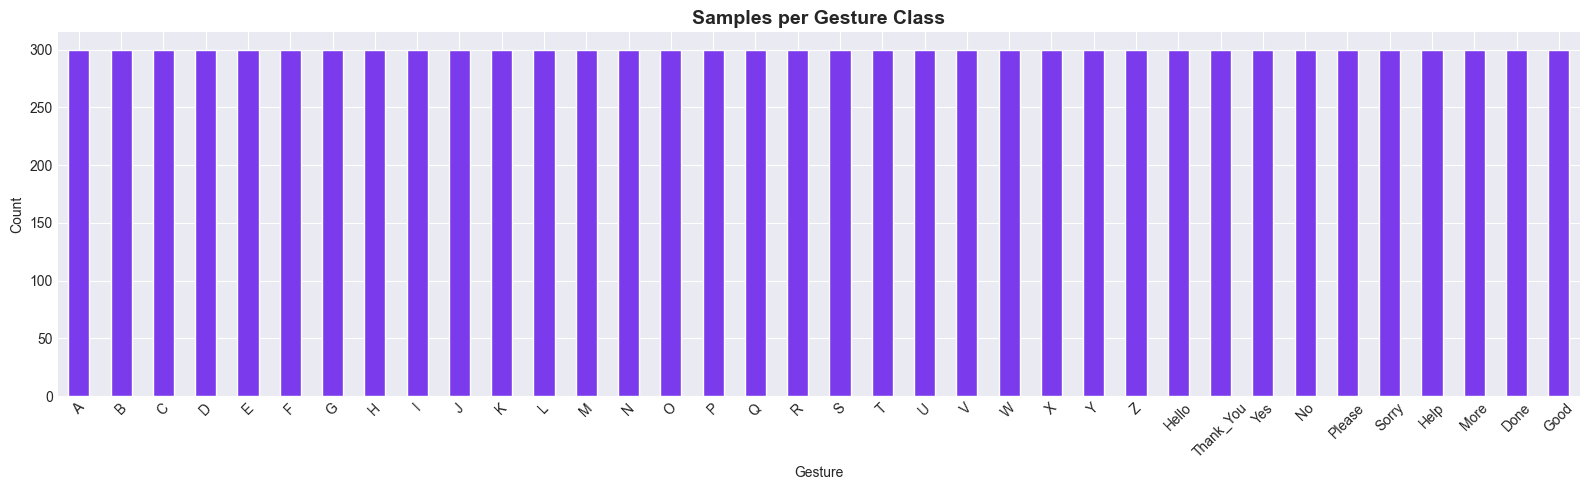

In [4]:
ig, ax = plt.subplots(figsize=(16, 5))
df["label"].value_counts().plot(kind="bar", ax=ax, color="#7c3aed", edgecolor="white")
ax.set_title("Samples per Gesture Class", fontsize=14, fontweight="bold")
ax.set_xlabel("Gesture")
ax.set_ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Landmark Feature Distributions (first 6 features)

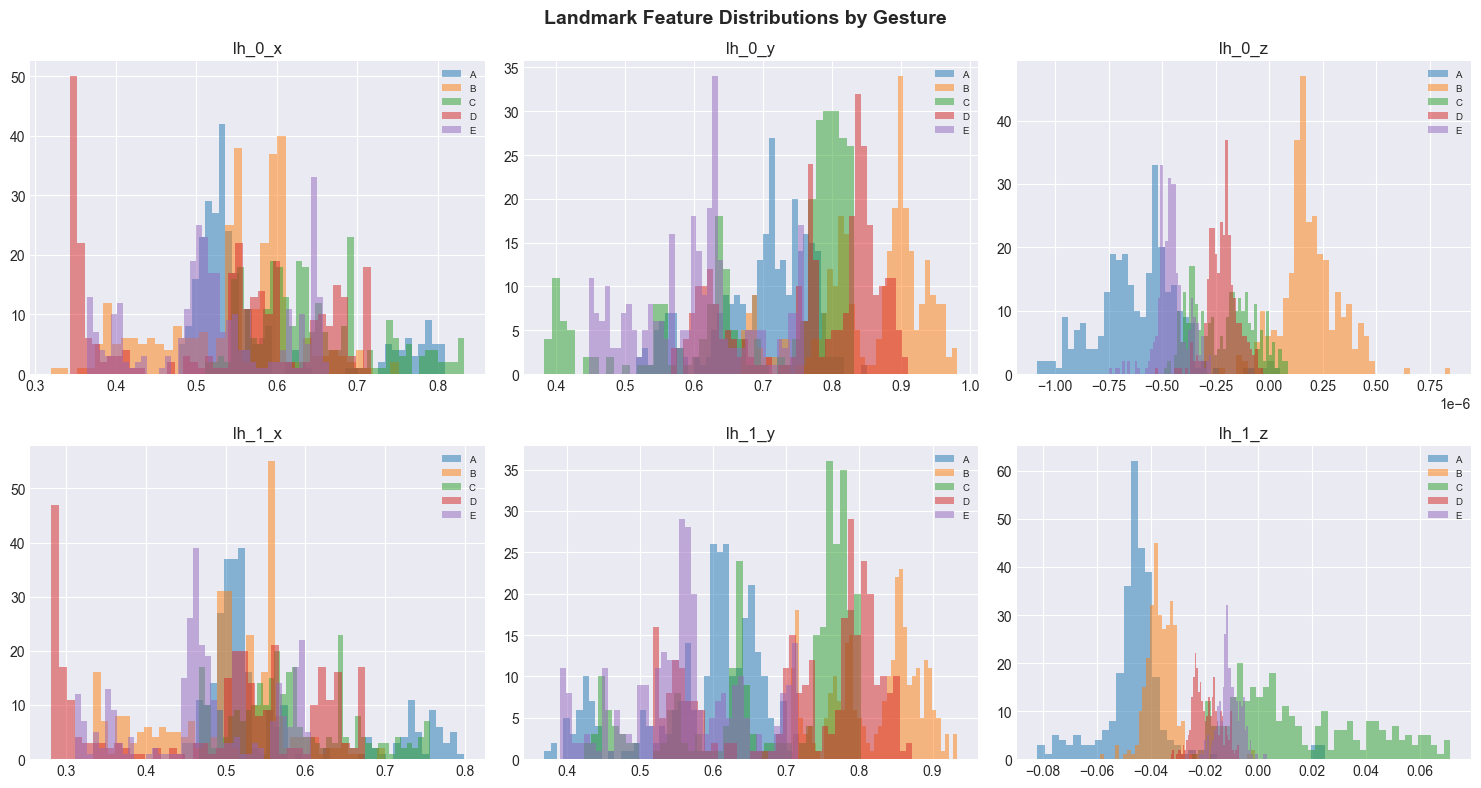

In [5]:
feature_cols = [c for c in df.columns if c != "label"][:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(feature_cols):
    ax = axes[i//3][i%3]
    for gesture in df["label"].unique()[:5]:
        subset = df[df["label"] == gesture][col].dropna()
        ax.hist(subset, bins=40, alpha=0.5, label=gesture)
    ax.set_title(col)
    ax.legend(fontsize=7)
plt.suptitle("Landmark Feature Distributions by Gesture", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Missing Value Heatmap (NaN = hand not detected)

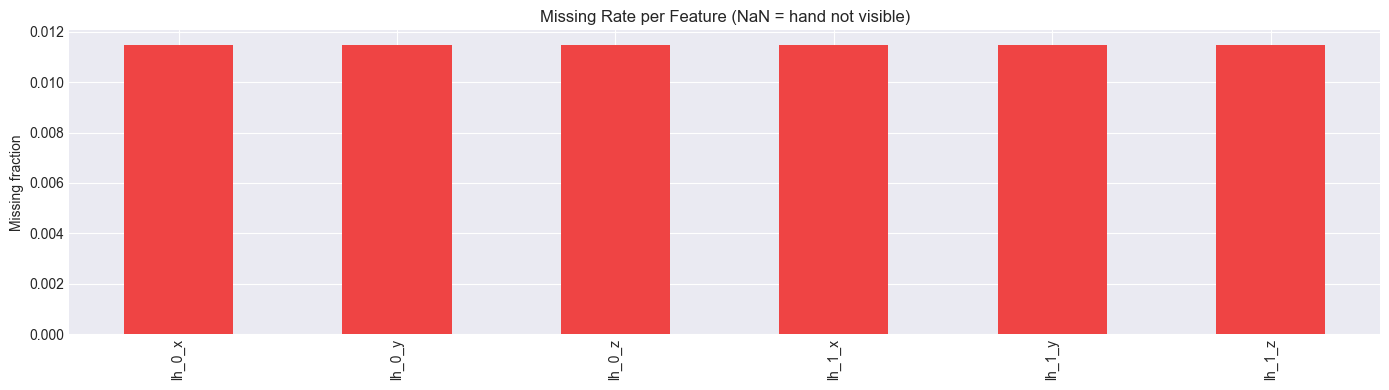

In [6]:
missing = df[feature_cols].isnull().mean().sort_values(ascending=False)[:30]
plt.figure(figsize=(14, 4))
missing.plot(kind="bar", color="#ef4444")
plt.title("Missing Rate per Feature (NaN = hand not visible)")
plt.ylabel("Missing fraction")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 5. PCA Visualisation — Do gesture clusters separate?

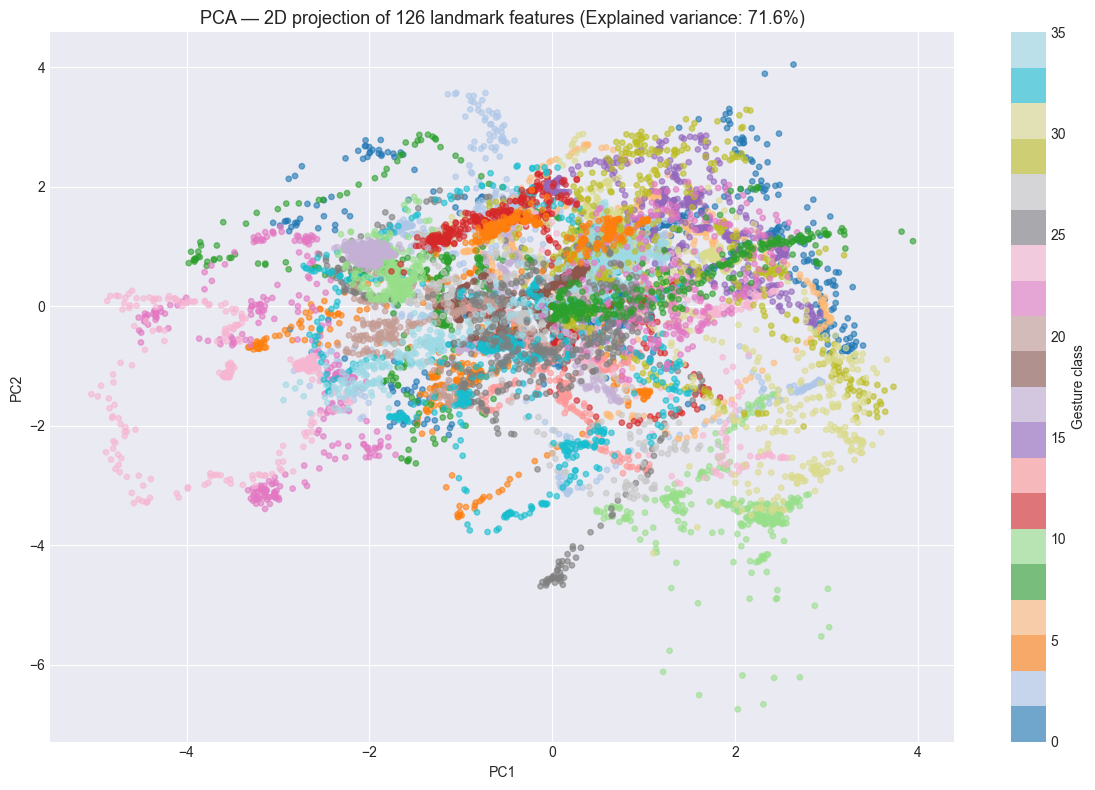

In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

X = df[feature_cols].values
y_raw = df["label"].values

imp = SimpleImputer(strategy="mean")
X_imp = imp.fit_transform(X)
X_scaled = StandardScaler().fit_transform(X_imp)

le = LabelEncoder()
y = le.fit_transform(y_raw)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="tab20", alpha=0.6, s=15)
plt.colorbar(scatter, label="Gesture class")
plt.title(f"PCA — 2D projection of 126 landmark features (Explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%)", fontsize=13)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.show()